In [1]:
import sklearn
print(sklearn.__version__)

1.6.1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint,uniform
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,OrdinalEncoder,LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
import warnings
warnings.simplefilter("ignore", UserWarning)

In [3]:
df = pd.read_csv("human_cognitive_performance.csv")
df.shape

(80000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB


In [5]:
bins = [-1, 40, 70, 100]
labels = ['Low', 'Medium', 'High']
df['Cognitive_Score_Level'] = pd.cut(df['Cognitive_Score'], bins=bins, labels=labels)

# 1. Total count check (should be 80,000)
print(f"Total Rows: {len(df)}")

# 2. Level distribution check
print(df['Cognitive_Score_Level'].value_counts())

Total Rows: 80000
Cognitive_Score_Level
Medium    34595
High      26374
Low       19031
Name: count, dtype: int64


In [6]:
df = df.drop(columns = ["User_ID","Cognitive_Score","AI_Predicted_Score"])

In [7]:
df.head()

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score_Level
0,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,Low
1,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,Medium
2,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,Low
3,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,High
4,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,High


In [8]:
df.isnull().sum()

Age                      0
Gender                   0
Sleep_Duration           0
Stress_Level             0
Diet_Type                0
Daily_Screen_Time        0
Exercise_Frequency       0
Caffeine_Intake          0
Reaction_Time            0
Memory_Test_Score        0
Cognitive_Score_Level    0
dtype: int64

In [9]:

df.duplicated().sum()

np.int64(0)

In [10]:
num_df = df.select_dtypes(["int","float"])

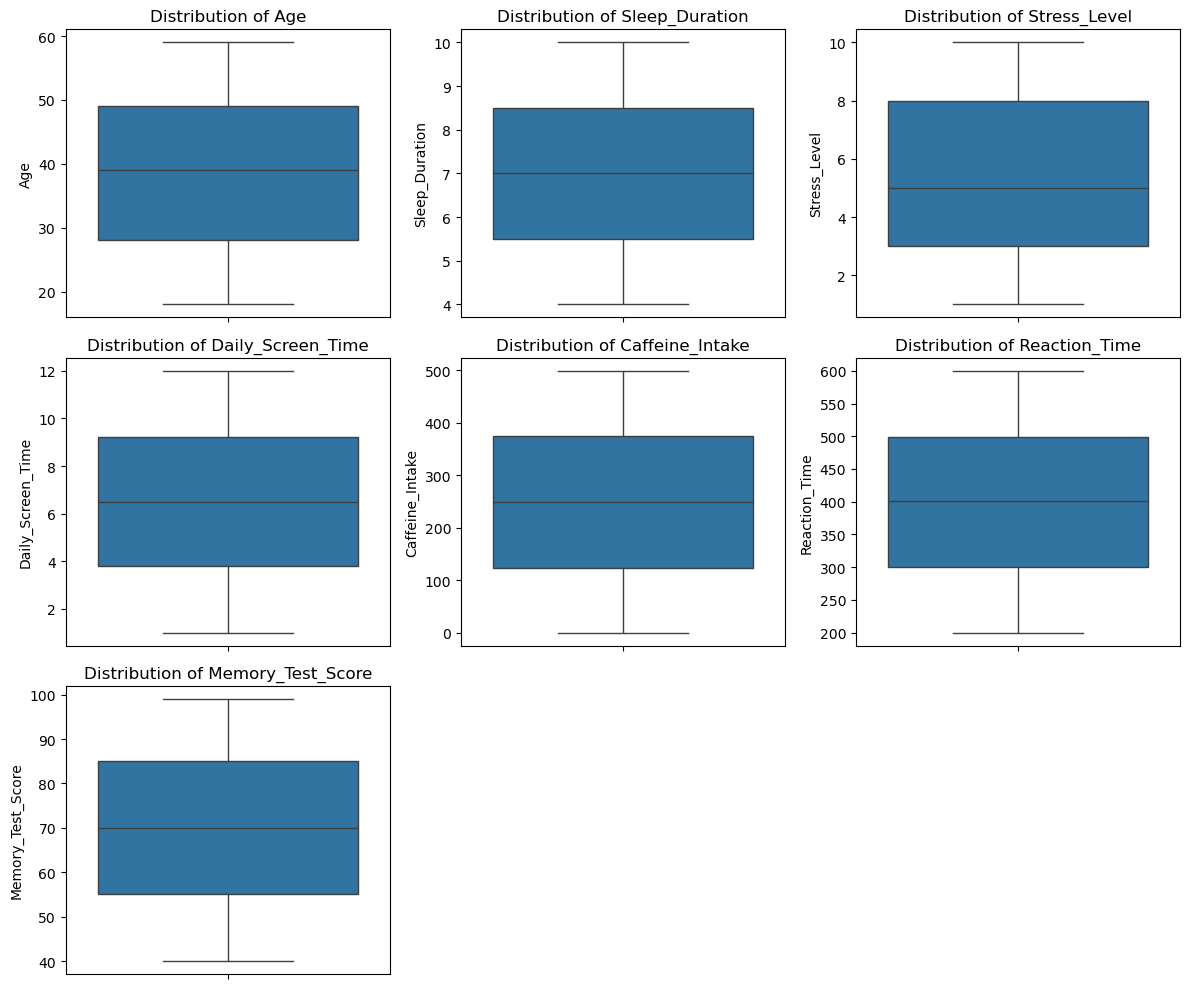

In [11]:
plt.figure(figsize=(12,10))
for i,col in enumerate(num_df.columns,1):
    plt.subplot((len(num_df.columns)//3)+1,3,i)    
    sns.boxplot(data=num_df,y=col)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

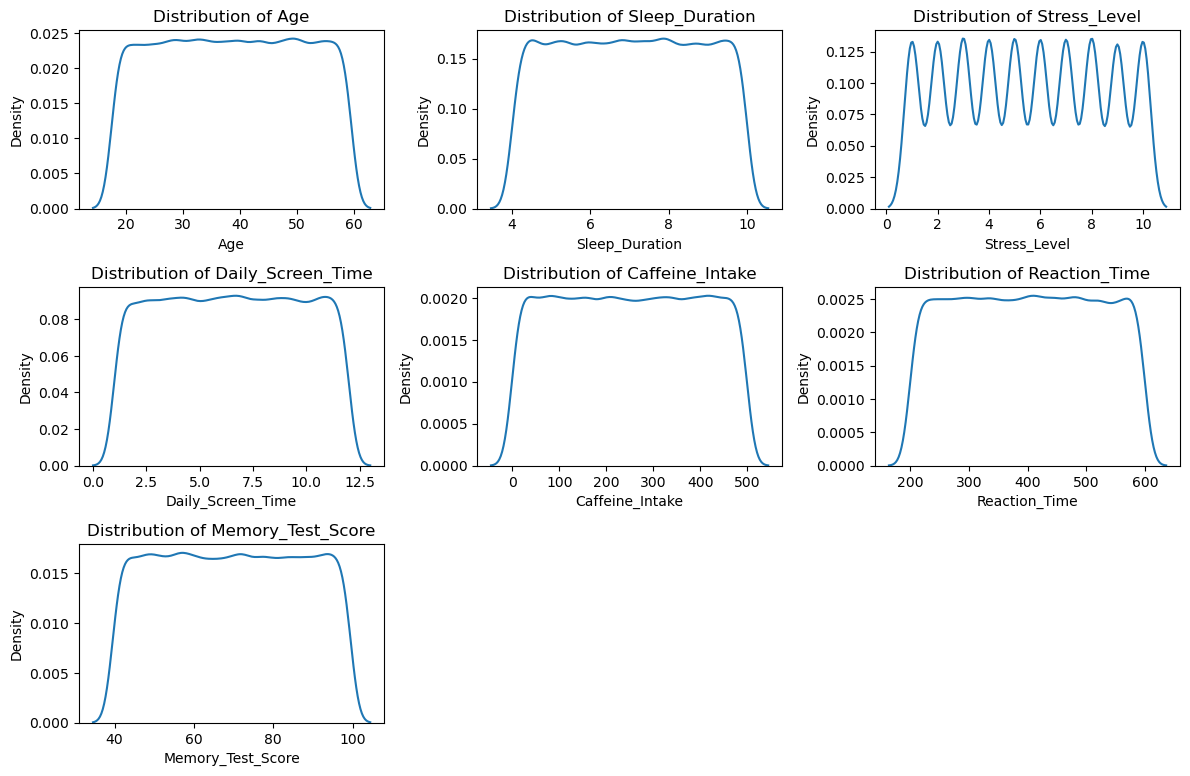

In [12]:
# to check the data distribution for numerical cols
plt.figure(figsize=(12,10))
for i,col in enumerate(num_df.columns,1):
    plt.subplot(4,3,i)
    sns.kdeplot(data=num_df,x=col)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [13]:
cat_df = df[['Gender','Diet_Type','Exercise_Frequency']]
for i in cat_df:
    print(df[i].value_counts(),"\n")

Gender
Female    38404
Male      38322
Other      3274
Name: count, dtype: int64 

Diet_Type
Non-Vegetarian    47986
Vegetarian        24136
Vegan              7878
Name: count, dtype: int64 

Exercise_Frequency
Medium    31990
Low       31896
High      16114
Name: count, dtype: int64 



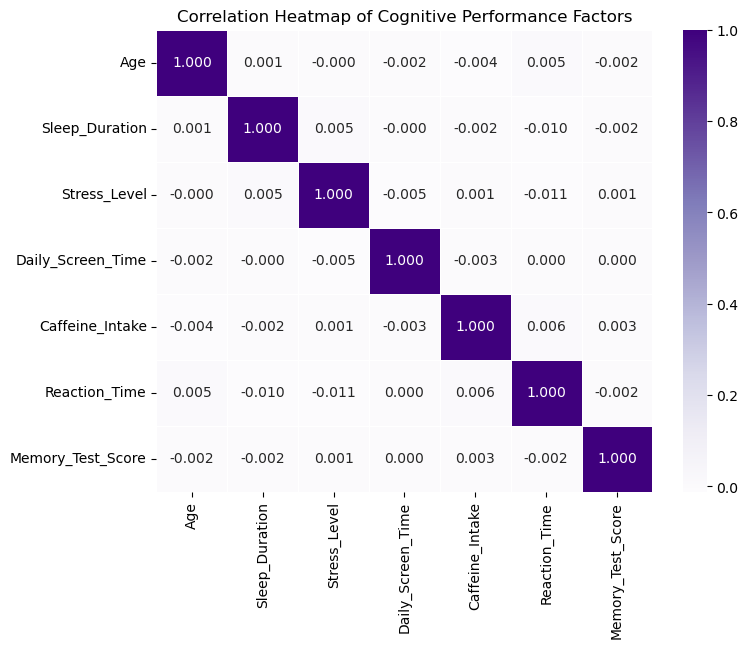

In [14]:
num_df = df.select_dtypes(['int','float'])
corr_matrix = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Purples', fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap of Cognitive Performance Factors')
plt.show()

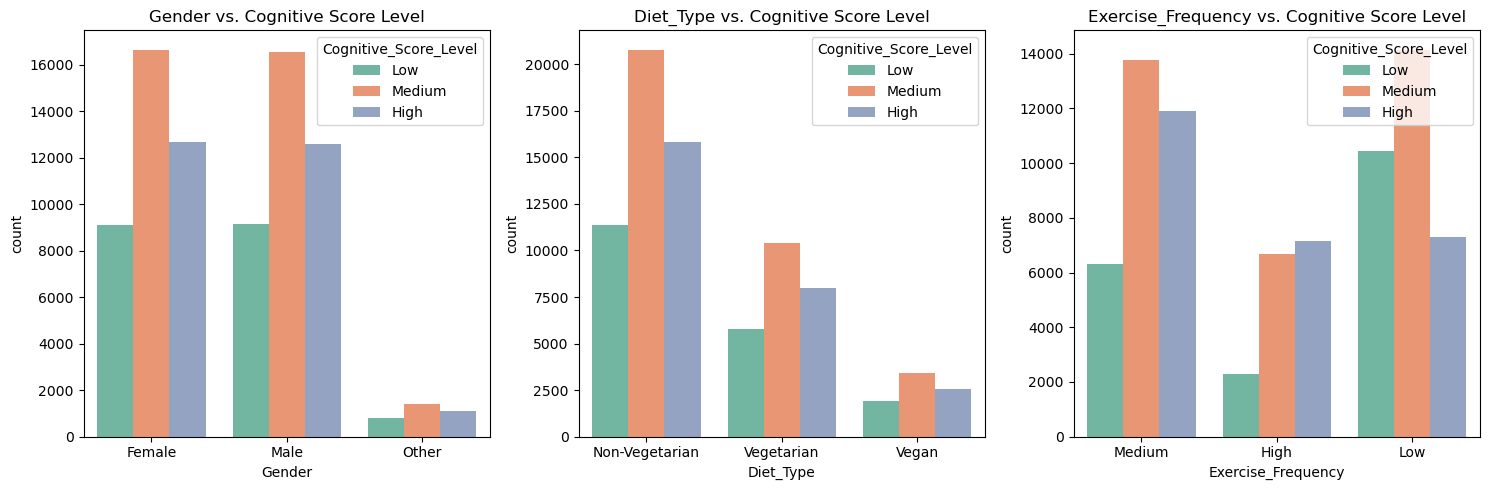

In [15]:
# 8. EDA: Feature-Target Relationship (Added for project depth)
# --------------------------------------------------------------------------------

plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_df.columns):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df, x=col, hue='Cognitive_Score_Level', palette='Set2')
    plt.title(f'{col} vs. Cognitive Score Level')
    plt.tight_layout()

plt.show()

In [16]:
# target variable
y = df["Cognitive_Score_Level"]
X = df.drop(columns = ["Cognitive_Score_Level"],axis =1)
print(y.shape)
print(X.shape)

(80000,)
(80000, 10)


In [17]:
# 1. Group features by type
num_cols = ['Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score']
ord_cols = ['Exercise_Frequency']
cat_cols = ['Gender', 'Diet_Type']

# 2. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('ord', OrdinalEncoder(categories=[['Low','Medium','High']]), ord_cols),
        ('cat', OneHotEncoder(drop='first',handle_unknown='ignore'), cat_cols)
    ])


In [18]:
# Encode the target variable (y) for models like XGBoost/LGBM which prefer integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [19]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,random_state = 42,stratify=y_encoded)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(64000, 10)
(16000, 10)
(64000,)
(16000,)


In [24]:
# --- 5. Base Model Definitions and Pipelines ---

models = {
    "Logistic Regression": LogisticRegression(random_state=42,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42,objective='multi:softprob',eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(random_state=42, objective='multiclass', verbose=-1)
}

** Training and Evaluating: Logistic Regression **
Training Accuracy: 0.9695
Testing Accuracy : 0.9669
Classification report:
               precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      3806
         1.0       0.96      0.96      0.96      6919
         2.0       0.97      0.97      0.97      5275

    accuracy                           0.97     16000
   macro avg       0.97      0.97      0.97     16000
weighted avg       0.97      0.97      0.97     16000



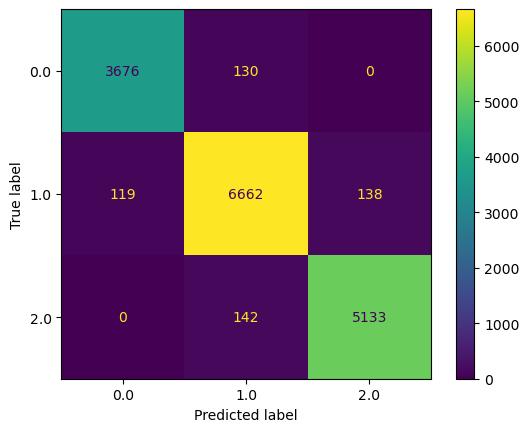

** Training and Evaluating: Decision Tree **
Training Accuracy: 1.0000
Testing Accuracy : 0.8834
Classification report:
               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      3806
         1.0       0.87      0.86      0.86      6919
         2.0       0.91      0.91      0.91      5275

    accuracy                           0.88     16000
   macro avg       0.88      0.89      0.89     16000
weighted avg       0.88      0.88      0.88     16000



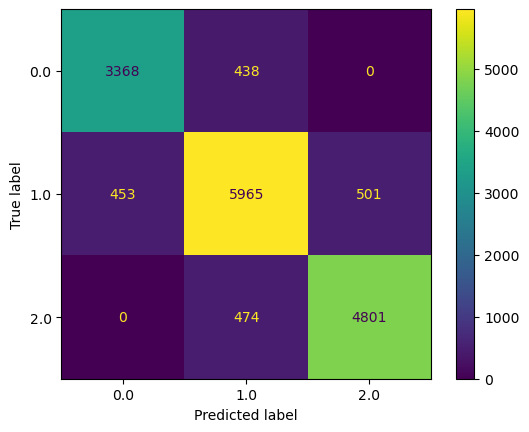

** Training and Evaluating: Random Forest **
Training Accuracy: 1.0000
Testing Accuracy : 0.9437
Classification report:
               precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      3806
         1.0       0.92      0.95      0.94      6919
         2.0       0.96      0.95      0.96      5275

    accuracy                           0.94     16000
   macro avg       0.95      0.94      0.94     16000
weighted avg       0.94      0.94      0.94     16000



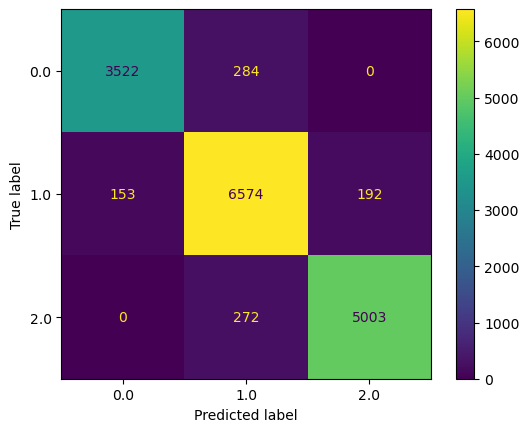

** Training and Evaluating: XGBoost **
Training Accuracy: 0.9993
Testing Accuracy : 0.9699
Classification report:
               precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      3806
         1.0       0.96      0.97      0.97      6919
         2.0       0.98      0.97      0.98      5275

    accuracy                           0.97     16000
   macro avg       0.97      0.97      0.97     16000
weighted avg       0.97      0.97      0.97     16000



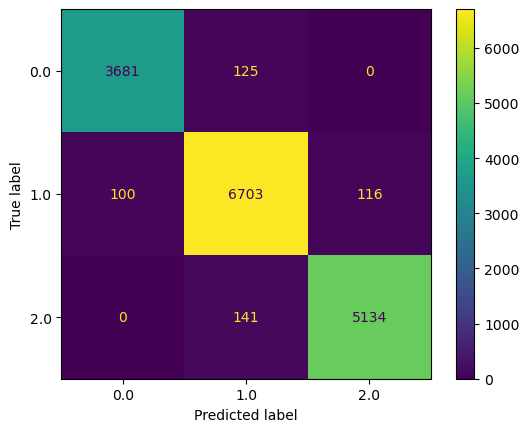

** Training and Evaluating: LightGBM **
Training Accuracy: 0.9850
Testing Accuracy : 0.9628
Classification report:
               precision    recall  f1-score   support

         0.0       0.97      0.95      0.96      3806
         1.0       0.95      0.97      0.96      6919
         2.0       0.97      0.97      0.97      5275

    accuracy                           0.96     16000
   macro avg       0.97      0.96      0.96     16000
weighted avg       0.96      0.96      0.96     16000



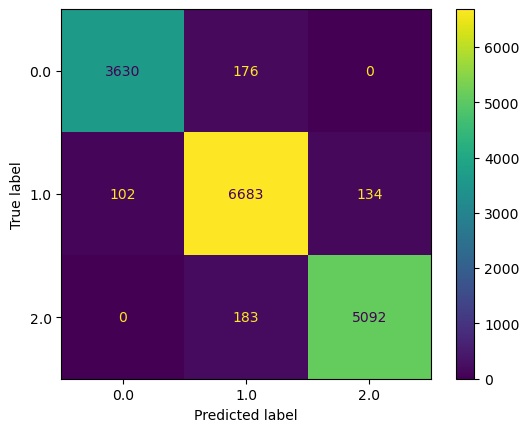

In [25]:
for name, model in models.items():
    print(f"** Training and Evaluating: {name} **")

    # a) Create pipeline in a single line
    pipe = make_pipeline(preprocessor, model)

    pipe.fit(X_train,y_train)

    y_train_pred = pipe.predict(X_train)

    # ---- Testing predictions ----
    y_test_pred = pipe.predict(X_test)

    # ---- Accuracy ----
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")

    print("Classification report:\n",classification_report(y_test,y_test_pred))

    ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred)
    plt.show()

In [26]:
best_models = {}

# ---------------- Decision Tree ----------------
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_params = {
    'model__max_depth': randint(2, 30),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 20),
    'model__criterion': ['gini', 'entropy']
}

dt_search = RandomizedSearchCV(dt_pipe, dt_params, n_iter=30,
                               cv=3, scoring='accuracy', n_jobs=-1)
dt_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['Age',
                                                                                'Sleep_Duration',
                                                                                'Stress_Level',
                                                                                'Daily_Screen_Time',
                                                                                'Caffeine_Intake',
                                                                                'Reaction_Time',
                                                                                'Memory_Test_Score']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Low',
                                                                                                           'Medium',
                                                                                                           'High']]),
                                                                               ['Exercise_Frequency']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='firs...
                   param_distributions={'model__criterion': ['gini', 'entropy'],
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDC31002F0>,
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDD38F3D90>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDD38F3110>},
                   scoring='accuracy')

In [27]:
# ---------------- Logistic Regression ----------------
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_params = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': uniform(0.01, 10)
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': uniform(0.01, 10)
    }
]

lr_search = RandomizedSearchCV(lr_pipe, lr_params, n_iter=20,
                               cv=3, scoring='accuracy', n_jobs=-1)
lr_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['Age',
                                                                                'Sleep_Duration',
                                                                                'Stress_Level',
                                                                                'Daily_Screen_Time',
                                                                                'Caffeine_Intake',
                                                                                'Reaction_Time',
                                                                                'Memory_Test_Score']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Low',
                                                                                                           'Medium',
                                                                                                           'High']]),
                                                                               ['Exercise_Frequency']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='firs...
                   n_iter=20, n_jobs=-1,
                   param_distributions=[{'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001DDC8FB6660>,
                                         'model__penalty': ['l1', 'l2'],
                                         'model__solver': ['liblinear']},
                                        {'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001DDD312D810>,
                                         'model__penalty': ['l1', 'l2'],
                                         'model__solver': ['saga']}],
                   scoring='accuracy')

In [28]:
# ---------------- Random Forest ----------------
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_params = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(5, 40),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
}

rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=30,
                               cv=3, scoring='accuracy', n_jobs=-1)
rf_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['Age',
                                                                                'Sleep_Duration',
                                                                                'Stress_Level',
                                                                                'Daily_Screen_Time',
                                                                                'Caffeine_Intake',
                                                                                'Reaction_Time',
                                                                                'Memory_Test_Score']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Low',
                                                                                                           'Medium',
                                                                                                           'High']]),
                                                                               ['Exercise_Frequency']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='firs...
                   param_distributions={'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDD37BD5B0>,
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDC8B62E00>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDD30528D0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDC33F4050>},
                   scoring='accuracy')

In [29]:
# ---------------- XGBoost ----------------
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        random_state=42
    ))
])

xgb_params = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.3),
}

xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=30,
                                cv=3, scoring='accuracy', n_jobs=-1)
xgb_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['Age',
                                                                                'Sleep_Duration',
                                                                                'Stress_Level',
                                                                                'Daily_Screen_Time',
                                                                                'Caffeine_Intake',
                                                                                'Reaction_Time',
                                                                                'Memory_Test_Score']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Low',
                                                                                                           'Medium',
                                                                                                           'High']]),
                                                                               ['Exercise_Frequency']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='firs...
                   param_distributions={'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001DDD312EE90>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDCAF26A50>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDC8B63020>},
                   scoring='accuracy')

In [32]:
# ---------------- LightGBM ----------------
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        objective='multiclass',
        num_class=3,
        random_state=42,
        verbose=-1
    ))
])

lgbm_params = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 12),
    'model__learning_rate': uniform(0.01, 0.3),
}

lgbm_search = RandomizedSearchCV(lgbm_pipe, lgbm_params, n_iter=30,
                                 cv=3, scoring='accuracy', n_jobs=-1)
lgbm_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               ['Age',
                                                                                'Sleep_Duration',
                                                                                'Stress_Level',
                                                                                'Daily_Screen_Time',
                                                                                'Caffeine_Intake',
                                                                                'Reaction_Time',
                                                                                'Memory_Test_Score']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Low',
                                                                                                           'Medium',
                                                                                                           'High']]),
                                                                               ['Exercise_Frequency']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='firs...
                   param_distributions={'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001DDD37BD350>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDCBF87A10>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001DDD305F020>},
                   scoring='accuracy')

In [33]:
best_models['Decision Tree'] = dt_search.best_estimator_
best_models['Logistic Regression'] = lr_search.best_estimator_
best_models['Random Forest'] = rf_search.best_estimator_
best_models['XGBoost'] = xgb_search.best_estimator_
best_models['LightGBM'] = lgbm_search.best_estimator_


===== Decision Tree =====
Train Accuracy   : 0.9952
Test Accuracy    : 0.8905
F1 Score         : 0.8922
Training Time(s) : 0.6479

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.89      0.89      3806
         1.0       0.87      0.87      0.87      6919
         2.0       0.91      0.91      0.91      5275

    accuracy                           0.89     16000
   macro avg       0.89      0.89      0.89     16000
weighted avg       0.89      0.89      0.89     16000



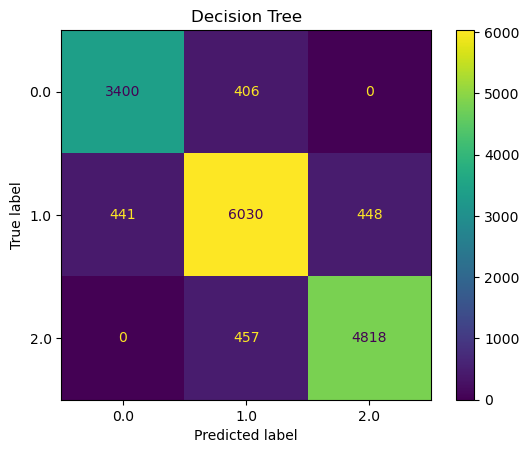


===== Logistic Regression =====
Train Accuracy   : 0.9696
Test Accuracy    : 0.9673
F1 Score         : 0.9679
Training Time(s) : 6.3512

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      3806
         1.0       0.96      0.96      0.96      6919
         2.0       0.97      0.97      0.97      5275

    accuracy                           0.97     16000
   macro avg       0.97      0.97      0.97     16000
weighted avg       0.97      0.97      0.97     16000



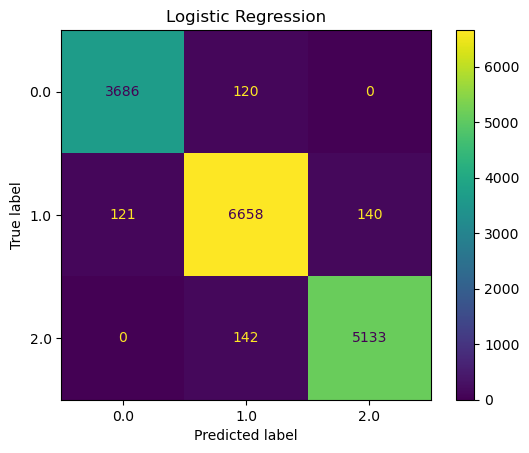


===== Random Forest =====
Train Accuracy   : 1.0000
Test Accuracy    : 0.9449
F1 Score         : 0.9459
Training Time(s) : 40.8019

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.93      0.95      3806
         1.0       0.92      0.95      0.94      6919
         2.0       0.96      0.95      0.95      5275

    accuracy                           0.94     16000
   macro avg       0.95      0.94      0.95     16000
weighted avg       0.95      0.94      0.95     16000



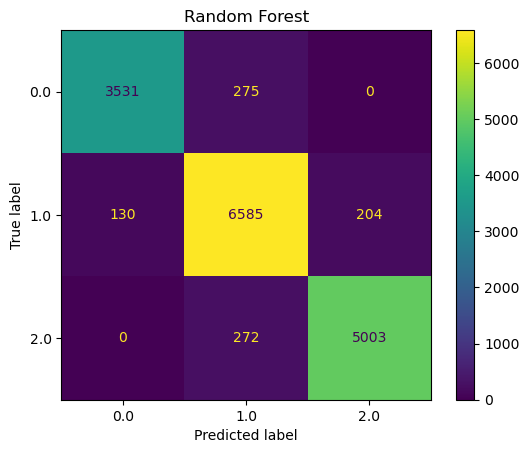


===== XGBoost =====
Train Accuracy   : 0.9987
Test Accuracy    : 0.9788
F1 Score         : 0.9791
Training Time(s) : 4.8965

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3806
         1.0       0.97      0.98      0.98      6919
         2.0       0.99      0.98      0.98      5275

    accuracy                           0.98     16000
   macro avg       0.98      0.98      0.98     16000
weighted avg       0.98      0.98      0.98     16000



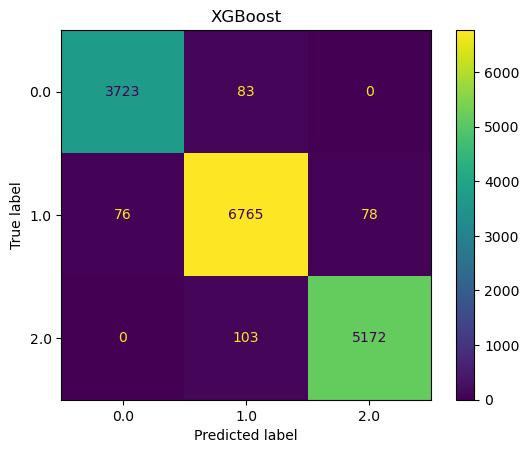


===== LightGBM =====
Train Accuracy   : 0.9967
Test Accuracy    : 0.9805
F1 Score         : 0.9806
Training Time(s) : 5.4615

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3806
         1.0       0.98      0.98      0.98      6919
         2.0       0.99      0.98      0.99      5275

    accuracy                           0.98     16000
   macro avg       0.98      0.98      0.98     16000
weighted avg       0.98      0.98      0.98     16000



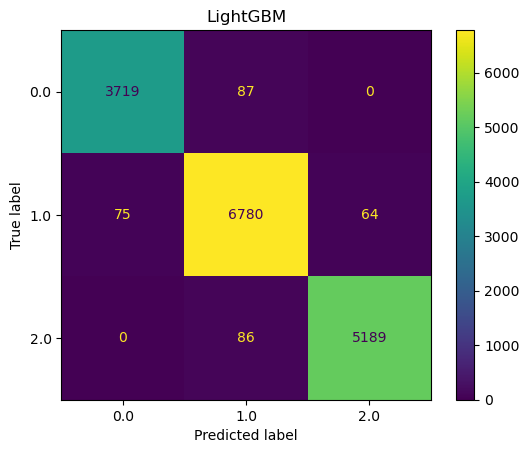

In [34]:
results = []

for name, pipe in best_models.items():
    print(f"\n===== {name} =====")

    #  Measure ONLY training time of best model
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()

    train_time = end_time - start_time

    # Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred  = pipe.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)

    # F1 score (macro for multi-class)
    f1 = f1_score(y_test, y_test_pred, average='macro')

    # Store results
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'F1 Score': f1,
        'Training Time (sec)': train_time
    })

    # Print results
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test Accuracy    : {test_acc:.4f}")
    print(f"F1 Score         : {f1:.4f}")
    print(f"Training Time(s) : {train_time:.4f}")

    print("\nClassification Report:\n",
          classification_report(y_test, y_test_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.title(name)
    plt.show()

In [35]:
# Convert to dataframe
results_df = pd.DataFrame(results)

print("\n========= MODEL COMPARISON TABLE =========")
print(results_df)

#  Best model based on F1 score
best_model_row = results_df.loc[results_df['F1 Score'].idxmax()]

print("\n BEST MODEL BASED ON F1 SCORE:")
print(best_model_row)


========= MODEL COMPARISON TABLE =========
                 Model  Train Accuracy  Test Accuracy  F1 Score  \
0        Decision Tree        0.995172       0.890500  0.892179   
1  Logistic Regression        0.969594       0.967313  0.967939   
2        Random Forest        1.000000       0.944937  0.945883   
3              XGBoost        0.998703       0.978750  0.979127   
4             LightGBM        0.996672       0.980500  0.980648   

   Training Time (sec)  
0             0.647858  
1             6.351194  
2            40.801888  
3             4.896504  
4             5.461548  

 BEST MODEL BASED ON F1 SCORE:
Model                  LightGBM
Train Accuracy         0.996672
Test Accuracy            0.9805
F1 Score               0.980648
Training Time (sec)    5.461548
Name: 4, dtype: object


In [36]:
lgbm_model = best_models['LightGBM'].named_steps['model']
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__Age', 'num__Sleep_Duration', 'num__Stress_Level',
       'num__Daily_Screen_Time', 'num__Caffeine_Intake',
       'num__Reaction_Time', 'num__Memory_Test_Score',
       'ord__Exercise_Frequency', 'cat__Gender_Male', 'cat__Gender_Other',
       'cat__Diet_Type_Vegan', 'cat__Diet_Type_Vegetarian'], dtype=object)

In [37]:
lgbm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

lgbm_importance.head(10)

,Feature,Importance
5,num__Reaction_Time,3329
6,num__Memory_Test_Score,2126
3,num__Daily_Screen_Time,1185
2,num__Stress_Level,1089
1,num__Sleep_Duration,871
4,num__Caffeine_Intake,847
7,ord__Exercise_Frequency,778
0,num__Age,80
10,cat__Diet_Type_Vegan,16
8,cat__Gender_Male,7


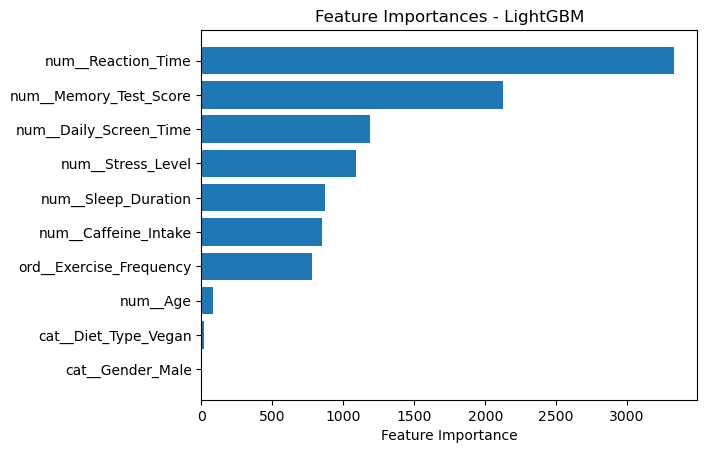

In [38]:
top_n = 10
plt.figure()
plt.barh(
    lgbm_importance['Feature'][:top_n][::-1],
    lgbm_importance['Importance'][:top_n][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Feature Importances - LightGBM")
plt.show()

In [39]:
import pickle
best_lgbm = best_models["LightGBM"]
pickle.dump(best_lgbm, open("lgbm_model.pkl","wb"))

print("Model saved successfully.")

Model saved successfully.


In [40]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

with open("lgbm_model.pkl","rb") as f:
    model = pickle.load(f)

columns = ['Age', 'Gender', 'Sleep_Duration', 'Stress_Level',
       'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency', 'Caffeine_Intake', 'Reaction_Time',
       'Memory_Test_Score']

sample_input = pd.DataFrame([[63,'Male',8.2,6,'Vegetarian',5.7,'Low',23,400,49]],columns=columns)

prediction = model.predict(sample_input)

# Show result
print("Prediction:","High" if prediction==2  else "Medium" if prediction ==1 else "Low")

Prediction: Medium
